In [ ]:
# open AI key 등록
import os
OPENAI_API_KEY="본인의 OpenAI API 키를 입력하세요"

In [2]:
# 현재 노트북 커널에 환경변수 등록
os.environ['OPENAI_API_KEY']=OPENAI_API_KEY

In [ ]:
# LangSmith API key등록
LANGSMITH_TRACING="true"
LANGSMITH_ENDPOINT="https://api.smith.langchain.com"
LANGSMITH_API_KEY="본인의 LangSmith API 키를 입력하세요"
LANGSMITH_PROJECT="langchain0422"

# 현재 노트북 커널에 환경변수 등록
os.environ['LANGSMITH_TRACING']=LANGSMITH_TRACING
os.environ['LANGSMITH_ENDPOINT']=LANGSMITH_ENDPOINT
os.environ['LANGSMITH_API_KEY']=LANGSMITH_API_KEY
os.environ['LANGSMITH_PROJECT']=LANGSMITH_PROJECT

In [4]:
# 필요 패키지 설치
!pip install -U langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 33.0 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28


# 프롬프트 작성 원칙
- 모델이 최대한 정확하고 유용한 정보를 제공할 수 있도록 효과적인 프롬프트를 작성하는 것이 매우 중요

- 명확성과 구체성
  - 질문은 명확하고 구체적이어야 함 (모호한 질문은 LLM 모델의 혼란을 초래)
  - 예시:  "주식 시장은 ?" -> "다음 주 주식 시장에 영향을 줄 수 있는 예정된 이벤트들은 무엇일까?"

- 배경 정보 포함
  - 모델이 문맥을 이해할 수 있도록 필요한 배경 정보 제공 (환각 현상(hallucination) 감소 및 관련성 높은 응답 생성)
  - 예시: "2020년 미국 대선의 결과를 바탕으로 현재 정치 상황에 대한 분석을 해주세요"
  
- 간결함
  - 핵심 정보에 초점을 맞추고, 불필요한 정보는 배제 (복잡하면 덜 중요한 부분에 집중하거나 상당한 영향을 받는 문제 발생)
  - 예시: "2021년에 발표된 삼성전자의 ESG 보고서를 요약해주세요."

- 열린 질문 사용
  - 열린 질문을 통해 모델이 자세하고 풍부한 답변을 제공하도록 유도 (예/아니오로 답변하는 질문보다는 많은 답변을 요구하는 질문)
  - 예시: "신재생에너지에 대한 최신 연구 동향은 무엇인가요?"

- 명확한 목표 설정
  - 얻고자 하는 정보나 결과의 유형을 정확하게 정의 (명확한 지침에 따라 응답을 생성)
  - 예시: "AI 윤리에 대한 문제점과 해결 방안을 요약하여 설명해주세요."

- 언어와 문체
  - 대화의 맥락에 적합한 언어와 문체를 선택 (상황에 맞는 표현 선택)
  - 예시: 공식적인 보고서를 요청하는 경우, "XX 보고서에 대한 전문적인 요약을 부탁드립니다."와 같이 정중한 문체를 사용


# 프롬프트 프레임워크(방식) 예시
### 후가츠식 프롬프트
- 참고 : https://brunch.co.kr/@pletalk/158
- 일본 Note사의 CXO 후가츠 타카유키가 개발한 ChatGPT용 프롬프트 작성을 위한 프레임워크
- ChatGPT를 효율적이고 올바르게 활용할 수 있도록 만들어진 작성 방식

- 형식
  - 지침(명령서), 제약조건, 입력문, 출력문으로 구분
  - 지침과 제약조건 : 입력문을 어떻게 처리할 것인지에 대한 내용을 구체적으로 나열
  - 출력문 : ChatGPT의 답변을 출력
  

<pre>
# 지침:
당신은 {역할}입니다.
아래의 제약조건과 입력문을 기반으로, 최상의 결과를 출력하세요.

# 제약조건:
- 문자수는 {문자수}입니다.
- {제약조건들에 관한 텍스트}

# 입력문:
{입력문 텍스트}

# 출력문:
</pre>

### Chain of Thought (CoT)
- 복잡한 문제를 단계적으로 사고하게 만드는 프롬프트 설계 기법
- GPT 같은 언어 모델이 단순히 답을 “예/아니오”나 숫자로 내는 것이 아니라, 논리적 추론 과정을 거쳐 생각의 흐름을 따라가도록 유도하는 것이 핵심

- 구조

<pre>
[문제 또는 질문]
[Chain of Thought 유도 문장 → Step-by-step reasoning]
[최종 답변 또는 결론]
</pre>

- 작성 팁
  - 사고 흐름을 유도하는 가장 일반적인 표현
  - 논리를 말하게 유도
  - 문제를 세부적으로 나누어 생각하게 함
  - 마치 대화를 하듯 생각 흐름을 자연스럽게 표현
  - 사고의 첫 단계부터 유도

- CoT 구조의 프롬프트 템플릿

<pre>
아래의 단계적 질문 흐름을 따라 논리적으로 사고해줘:

Step 1: 문제 정의 → 사용자나 시장이 겪고 있는 문제를 설명해줘.  
Step 2: 제품 연결 → 해당 제품/서비스가 어떤 해결책을 제공하는지 설명해줘.  
Step 3: 공감 요소 → 타깃이 공감할 만한 포인트 3가지 도출해줘.  
Step 4: 콘텐츠 구상 → 영상이나 콘텐츠로 풀어낼 구체적 구성안을 HOOK, 본문, CTA로 나눠줘.  
Step 5: 바이럴 요소 → 콘텐츠가 퍼질 수 있는 대사, 편집, 음악 아이디어를 제안해줘.  
Step 6: 기대 효과 → 사용자 반응 및 마케팅 효과를 정리해줘.
</pre>

- 마케팅/콘텐츠 기획 프롬프트 예시

<pre>
아래의 단계별 질문 흐름을 따라, TikTok 숏폼 영상 기획을 논리적으로 구성해줘.
각 단계마다 간단한 설명과 함께 아이디어를 제시해.

Step 1: 문제 정의
→ MZ세대 직장인이 왜 단백질 보충이 필요하고, 기존 방식에 어떤 불편을 겪고 있는지 분석해줘.

Step 2: 제품 연결
→ 위 문제에 대해 단백질 음료가 어떤 해결책을 제시할 수 있는지 설명해줘.
특히 ‘환경 친화적’이라는 속성이 어떤 가치를 더하는지도 포함해줘.

Step 3: 타깃 공감 포인트 도출
→ 이 제품을 통해 타깃이 공감할 수 있는 포인트 3가지를 도출해줘.
(예: 간편함, 건강, 윤리적 소비 등)

Step 4: 콘텐츠 콘셉트 기획
→ 위에서 도출된 포인트를 바탕으로 1분 TikTok 영상의 콘셉트를 설명해줘.
HOOK (3초), 본문, CTA 구조로 구성하고, 구체적인 장면 예시도 포함해줘.

Step 5: 바이럴 요소 강화
→ 이 영상이 공유되거나 퍼질 수 있도록, 대사·편집·음악 등에서 반영할 수 있는 바이럴 요소를 2~3가지 제안해줘.

Step 6: 기대 효과 예측
→ 이 콘텐츠를 통해 기대할 수 있는 사용자 반응이나 브랜딩 효과를 논리적으로 정리해줘.
</pre>

# 프롬프트 탬플릿 (PromptTemplate) 구성 요소
- PromptTemplate : 단일 문장 또는 입력변수 등의 <font color=red>간단한 명령을 입력</font>하여 단일 문장 또는 <font color=red>간단한 응답을 생성</font>하는 데 사용되는 프롬프트를 구성할 수 있는 문자열 템플릿
  - <font color=red>지시</font> : 언어 모델에게 어떤 작업을 수행하도록 요청하는 구체적인 지시
  - <font color=red>예시</font> : 요청된 작업을 수행하는 방법에 대한 하나 이상의 예시
  - <font color=red>맥락</font> : 특정 작업을 수행하기 위한 추가적인 맥락
  - <font color=red>질문</font> : 어떤 답변을 요구하는 구체적인 질문

- 예시: 제품 리뷰 요약
  - 지시: "아래 제공된 제품 리뷰를 요약해주세요."
  - 예시: "예를 들어, '이 제품은 매우 사용하기 편리하며 배터리 수명이 길다'라는 리뷰는 '사용 편리성과 긴 배터리 수명이 특징'으로 요약할 수 있습니다."
  - 맥락: "리뷰는 스마트워치에 대한 것이며, 사용자 경험에 초점을 맞추고 있습니다."
  - 질문: "이 리뷰를 바탕으로 스마트워치의 주요 장점을 두세 문장으로 요약해주세요."


- 프롬프트 템플릿의 활용
  - 파라미터
    - <font color=red>template</font>: 문자열 템플릿 및 변수 설정 (중괄호 {} 사용)
    - <font color=red>input_variables</font> : PromptTemplate에서 사용되는 변수(중괄호 안에 들어갈 변수)의 이름을 정의하는 리스트

 - <font color=red>from_template()</font> : 문자열 템플릿을 직접 설정하는 함수

In [5]:
from langchain_openai.chat_models import ChatOpenAI # OpenAI 모델을 생성하는 도구
from langchain_core.prompts import PromptTemplate # 프롬프트 템플릿을 생성하는 도구

In [6]:
llm = ChatOpenAI() # 기본모델 생성

In [7]:
# 프롬프트 템플릿 생성 -> 사용자의 질의를 순서대로 쪼개서 답변을 유도하는 템플릿
QA_template = PromptTemplate.from_template('''
  Question : {q}
  Answer : Let's think step by step
''')
QA_template

PromptTemplate(input_variables=['q'], input_types={}, partial_variables={}, template="\n  Question : {q}\n  Answer : Let's think step by step\n")

In [ ]:
# input_variables=['q'] q라는 이름으로 입력변수 셋팅

In [8]:
# 템플릿으로 프롬프트 만들기
final_prompt = QA_template.format(q="Who won the FIFA World Cup in the year 1994?")
final_prompt

"\n  Question : Who won the FIFA World Cup in the year 1994?\n  Answer : Let's think step by step\n"

In [9]:
# 기본 LLM 호출하기
res = llm.invoke("Who won the FIFA World Cup in the year 1994?")

# 프롬프트 완성 후 LLM 호출하기
res2 = llm.invoke(final_prompt)

In [ ]:
print(res.content)
print(res2.content)

The FIFA World Cup in 1994 was won by Brazil.
1. The FIFA World Cup in 1994 was won by Brazil.
2. Brazil defeated Italy in the final match, which was held at the Rose Bowl in Pasadena, California.
3. The match ended in a 0-0 draw after extra time, and Brazil won 3-2 in a penalty shootout to claim their fourth FIFA World Cup title.


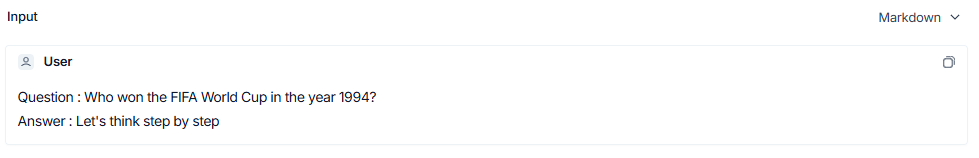

In [ ]:
# LangSmith에서도 다음과 같이 질문이 들어가는 것을 볼 수 있다.

# LangChain Expression Language (LCEL)

- <font color=red>체인을 구성하고 스트리밍, 배치 및 비동기 지원</font>을 기본적으로 제공하는 선언적 방법
- 기본적으로 파이썬 또는 타입스크립트/자바스크립트를 사용한 체인 만들기의 고수준 대안으로 코드를 사용해 구성할 때 사용하는 모든 기존 랭체인 생성자를 그대로 사용해 체인을 만들 수 있음

# | (파이프라인)으로 체인 생성하기 (LCEL)
  - LangChain 0.1.17 이후 버전부터 사용
  - <font color=red>|</font> 기호는 unix 파이프 연산자와 유사하며, <font color=red>서로 다른 구성 요소를 연결하고 한 구성 요소의 출력을 다음 구성 요소의 입력으로 전달</font>

  - prompt | llm | OutputParser와 같이 체인이 연결된 경우
<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/lcel1.png" width=60%>   
</center>

- 표준 인터페이스 함수을 이용하여 딕셔너리 형태로 값들을 전달
   - <font color=red>invoke()</font> : 딕셔너리 입력에 대해 체인을 호출
   - <font color=red>batch()</font> : 입력 목록에 대해 체인을 호출
   - <font color=red>stream()</font> : 응답의 청크를 스트리밍

In [ ]:
# 일반적으로 프롬프트-llm-파서 하나로 연결해서 사용 -> LCEL

In [6]:
# 문자열 파서
from langchain_core.output_parsers import StrOutputParser

In [11]:
# 파서 생성
# LLM의 출력을 단순문자열로 변환하는 역할
strParser = StrOutputParser()

In [12]:
# LCEL 사용하기 -> 하나의 파이프라인 만들기
QA_chain = QA_template | llm | strParser

In [16]:
QA_chain.invoke("Who won the FIFA World Cup in the year 1994?")

'Step 1: In the year 1994, the FIFA World Cup was held in the United States.\n\nStep 2: The winner of the FIFA World Cup in 1994 was the national team of Brazil.\n\nStep 3: Brazil defeated Italy in a penalty shootout after a 0-0 draw in the final match held at the Rose Bowl in Pasadena, California on July 17, 1994.\n\nStep 4: Therefore, Brazil won the FIFA World Cup in the year 1994.'

#### 번역기
- LCEL을 이용해 번역하는 체인을 만들어보자
- 프롬프트템플릿,LLM,Paser 만들어보기
- 모델 : model="gpt-4o-mini" 사용하기

In [17]:
# 모델생성
llm_4o = ChatOpenAI(model="gpt-4o-mini")

In [18]:
# 번역용 템플릿 생성
translate_template = PromptTemplate.from_template('''
  input : {text}
  위 input으로 들어온 글을 영어로 번역해줘.
  출력형식은 번역된 글자만 나오게 해줘.
''')
translate_template

PromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, template='\n  input : {text}\n  위 input으로 들어온 글을 영어로 번역해줘.\n  출력형식은 번역된 글자만 나오게 해줘.\n')

In [19]:
# 체인구성하기
translate_chain = translate_template | llm_4o | strParser

In [20]:
translate_chain.invoke("오늘은 비 예보 소식이 있다. 우산을 챙겨가세요.")

'Today there is a forecast of rain. Please take an umbrella.'

##### UI붙이기
https://www.gradio.app/

In [7]:
!pip install gradio

In [ ]:
# 응답을 처리하는 알고리즘의 사용자정의함수
# 일회성 응답만 준다. 대화내용을 기억하지는 못함 (메모리기능X)
def translate_response(message, history):
    return translate_chain.invoke(message)

In [ ]:
import gradio as gr

gr.ChatInterface(
    fn=translate_response,
).launch()

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dfdce8217c98c7ac05.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# 여러 역량에 대해서 두루두루 알고 / 요구사항정의 / 기획 + 정보처리기사

# Chat Model 클래스
- 기능: 메시지의 리스트를 입력으로 받고, 하나의 메시지를 반환
- <font color=red>대화형 메시지를 입력으로 사용하고 대화형 메시지를 출력</font>으로 반환하는 특수화된 LLM 모델
- 일반 텍스트를 사용하는 대신 <font color=red>대화의 맥락을 포함한 메시지를 처리</font>하며, 이를 통해 보다 더 <font color=red>자연스러운 대화를 가능</font>하게 함
- (예시) 사용자가 챗봇과 대화하는 상황에서, 사용자의 질문과 이전 대화 내용을 고려하여 적절한 답변을 생성

- Chat Model 인터페이스의 특징
  - 대화형 입력과 출력
    - 대화의 연속성을 고려하여 입력된 메시지 리스트를 기반으로 적절한 응답 메시지를 생성
    - 챗봇, 가상 비서, 고객 지원 시스템 등 대화 기반 서비스에 활용

  - 다양한 모델 제공 업체와의 통합
    - OpenAI, Cohere, Hugging Face 등 다양한 모델 제공 업체와의 통합을 지원
    - 개발자는 여러 소스의 Chat Models를 조합하여 활용

  - 다양한 작동 모드 지원
    - 랭체인은 동기(sync), 비동기(async), 배치(batching), 스트리밍(streaming) 모드에서 모델을 사용할 수 있는 기능을 제공
    - 다양한 애플리케이션 요구사항과 트래픽 패턴에 따라 유연한 대응이 가능

# ChatPromptTemplate
- <font color=red>대화형 상황에서 여러 메시지 입력을 기반으로 단일 메시지 응답을 생성</font>하는 데 사용
- 대화형 모델이나 챗봇 개발에 주로 사용
- 입력은 여러 메시지를 원소로 갖는 리스트로 구성되며, 각 메시지는 <font color=red>역할(role)</font>과 <font color=red>내용(content)</font>으로 구성

- Message 유형
  - <font color=red>SystemMessage</font>: 시스템 기능을 설명(지시문)
  - <font color=red>HumanMessage</font>: 사용자 질문을 입력
  - <font color=red>AIMessage</font>: AI 모델의 응답을 제공
  - <font color=red>FunctionMessage</font>: 특정 함수 호출의 결과를 표시
  - <font color=red>ToolMessage</font>: 도구 호출의 결과를 표시

- <font color=red>from_messages()</font> : 2개의 튜플 형태 메시지 리스트를 입력 받아, 각 메시지의 역할(type)과 내용(content)을 기반으로 프롬프트를 구성  
  - 사용자의 입력을 프롬프트에 동적으로 삽입하여, 최종적으로 대화형 상황을 반영한 메시지 리스트를 생성
  - 시스템은 기능을 설명하고, 사용자는 관련 질문을 입력

- 메시지에 출력 양식 포함 (System 메세지 사용하기)

In [8]:
from langchain_core.prompts import ChatPromptTemplate
# PromptTemplate : 1회성 요청과 응답을 구성 할 때 주로 사용
# ChatPromptTemplate : 멀티턴 대화를 기반으로 파이프라인을 구축 할 때 주로 사용

In [23]:
llm_4o.invoke("내가 무슨 음식을 좋아하는지 맞춰봐!").content
# 메모리 기능을 추가로 만들지 않으면 기억하지 못한다.

'음식 취향을 맞추는 것은 흥미로운 도전이네요! 어떤 음식을 좋아할까요? 매운 음식, 단 음식, 고기 요리, 채소 요리, 혹은 특정한 나라의 음식과 같은 힌트를 주시면 더 가까이 맞춰볼 수 있을 것 같아요!'

In [24]:
# 과거 대화내역을 프롬프트에 삽입해서 질의
chat_template = ChatPromptTemplate.from_messages([
    ('human','나는 떡볶이를 세상에서 가장 좋아해'),
    ('ai','아 떡볶이를 좋아하시는군요. 치즈떡볶이, 라볶이, 짜장떡볶이 중에 어떤걸 좋아하세요?'),
    ('human','나는 짜장떡볶이가 제일좋아.'),
    ('human',"{question}")
])

In [25]:
# 체인구성
simple_chain = chat_template | llm_4o | strParser

simple_chain.invoke("내가 좋아하는 음식이 뭐지?")

'당신이 좋아하는 음식은 짜장떡볶이입니다! 맛있고 독특한 조합이죠. 다른 좋아하는 음식도 있나요?'

### placeholder 추가하기
- 메모리 부분을 유연하게 만들기

In [26]:
memory = [
    ('human','나는 떡볶이를 세상에서 가장 좋아해'),
    ('ai','아 떡볶이를 좋아하시는군요. 치즈떡볶이, 라볶이, 짜장떡볶이 중에 어떤걸 좋아하세요?'),
    ('human','나는 짜장떡볶이가 제일좋아.')
]


# 과거 대화내역을 프롬프트에 삽입해서 질의
chat_template = ChatPromptTemplate.from_messages([
    ('placeholder', '{history}'), # 메모리가 삽입되는 구간
    ('human',"{question}")
])

In [27]:
# 체인구성 및 호출
simple_chain2 = chat_template | llm_4o | strParser

# 사용자 질문 입력
msg = input("질문 : ")
# 두개 이상의 입력인자를 호출하는 방법 -> 딕셔너리 형태로 구성
ai_res = simple_chain2.invoke({"question" : msg,
                               "history" : memory})

# 메모리 업데이트
memory.append(('human', msg))
memory.append(('ai', ai_res))

print("답변 : ", ai_res)

질문 : 오늘 어떤 떡볶이를 먹으면 좋을지 추천해줘
답변 :  짜장떡볶이를 좋아하신다면, 오늘은 짜장떡볶이에 새우나 오징어 같은 해산물을 추가해보는 건 어떨까요? 그러면 더욱 풍부한 맛을 즐길 수 있을 거예요. 혹은 기본 짜장떡볶이에 치즈를 추가해서 치즈짬뽕 같은 느낌으로 먹어보는 것도 추천해요! 요즘 날씨가 추우니 따뜻한 국물과 함께 먹으면 더 맛있겠네요. 어떤가요?


In [28]:
memory

[('human', '나는 떡볶이를 세상에서 가장 좋아해'),
 ('ai', '아 떡볶이를 좋아하시는군요. 치즈떡볶이, 라볶이, 짜장떡볶이 중에 어떤걸 좋아하세요?'),
 ('human', '나는 짜장떡볶이가 제일좋아.'),
 ('human', '오늘 어떤 떡볶이를 먹으면 좋을지 추천해줘'),
 ('ai',
  '짜장떡볶이를 좋아하신다면, 오늘은 짜장떡볶이에 새우나 오징어 같은 해산물을 추가해보는 건 어떨까요? 그러면 더욱 풍부한 맛을 즐길 수 있을 거예요. 혹은 기본 짜장떡볶이에 치즈를 추가해서 치즈짬뽕 같은 느낌으로 먹어보는 것도 추천해요! 요즘 날씨가 추우니 따뜻한 국물과 함께 먹으면 더 맛있겠네요. 어떤가요?')]

### UI 붙이기

In [ ]:
# 응답을 처리하는 알고리즘의 사용자정의함수
def chat_response(message, history):
  # 두개 이상의 입력인자를 호출하는 방법
  ai_res = simple_chain2.invoke({"question" : message,
                                "history" : memory})

  # 메모리 업데이트
  memory.append(('human', message))
  memory.append(('ai', ai_res))

  return ai_res

In [ ]:
import gradio as gr

gr.ChatInterface(
    fn=chat_response,
).launch()

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://04d55fd590ab1b78cc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
memory

[('human', '나는 떡볶이를 세상에서 가장 좋아해'),
 ('ai', '아 떡볶이를 좋아하시는군요. 치즈떡볶이, 라볶이, 짜장떡볶이 중에 어떤걸 좋아하세요?'),
 ('human', '나는 짜장떡볶이가 제일좋아.'),
 ('human', '내가 좋아하는 떡볶이 종류는 무엇인지 맞춰봐'),
 ('ai', '짜장떡볶이를 좋아하신다고 하셨으니, 짜장떡볶이가 맞겠네요! 다른 떡볶이도 좋아하시나요?'),
 ('human', '내가 가장 좋아하는 떡볶이 종류 무엇인지 맞춰봐!'),
 ('ai', '가장 좋아하시는 떡볶이 종류는 짜장떡볶이인 것 같아요! 맞나요?'),
 ('human', '정답이야~!!'),
 ('ai', '와, 맞혔네요! 짜장떡볶이 정말 맛있죠. 특별히 좋아하는 먹는 방법이나 팁이 있나요?')]

# 20260423

In [ ]:
# 여행지 추천하는 체인구성하기
recommend_template = ChatPromptTemplate.from_messages([
    ('system', "너는 일본여행 전문가야. 아래 input을 참고해서 겨울 일본 여행지를 추천해줘."),
    ('human', 'input : {input}'),
    ('system', '''
      답변시 아래 형식을 지켜서 출력해줘
      1. 여행지이름
        - 추천이유 :
        - 예상비용 :
      2. 여행지 이름
        - 추천이유 :
        - 예상비용 :
    ''')
])

In [12]:
# 모델생성
llm4o_mini = ChatOpenAI(model="gpt-4o-mini")
# 파서생성
strParser = StrOutputParser()

In [ ]:
# 체인구성
recommend_chain = recommend_template | llm4o_mini | strParser
print(recommend_chain.invoke("가족과 떠나기 좋은 여행지 3군데 알려줘"))

1. 니세코 (Niseko)
   - 추천이유 : 세계적으로 유명한 스키 리조트가 있어 가족 모두가 즐길 수 있는 다양한 겨울 스포츠를 경험할 수 있습니다. 아이들을 위한 스키 학교도 마련되어 있어 초보자도 안전하게 배울 수 있습니다.
   - 예상비용 : 1인당 1일 리프트 티켓 약 10,000엔, 숙박비는 15,000~30,000엔 (대가족 기준).

2. 홋카이도 삿포로 (Sapporo)
   - 추천이유 : 인기 있는 삿포로 눈축제(1월 ~ 2월)에 방문하면 거대한 눈 조각과 다양한 겨울 활동을 경험할 수 있습니다. 가족들과 함께 즐길 수 있는 무료 이벤트도 많습니다.
   - 예상비용 : 1인당 약 8,000~15,000엔 (식사 및 교통 포함).

3. 우베야마 (Ube Mountain)
   - 추천이유 : 아름다운 겨울 경치와 함께 온천을 즐길 수 있는 곳으로 가족과 함께 따뜻한 온천에 몸을 담그며 휴식을 취할 수 있습니다. 산책이나 눈 놀이도 가능합니다.
   - 예상비용 : 숙박비 약 10,000~20,000엔, 온천 이용료 1인당 약 1,500~3,000엔.


In [ ]:
# invoke() : 1개 데이터 통과 처리
# batch() : 여러개의 데이터를 통과 처리

# stream() : 응답결과를 쪼개서 출력, 한번에 많은양을 효과적으로 처리하기위해 (응답데이터 효율적으로 관리)

- batch() : 입력 리스트에 대해 chain을 호출하는 함수

In [ ]:
질문리스트 = ["가족과 떠나기 좋은 여행지 3개 알려줘",
              "친구와 밥먹기 좋은곳 2가지"]
recommend_chain.batch(질문리스트)

- stream() : 결과메세지를 청크단위로 받는 함수
  

In [ ]:
rs = recommend_chain.stream("친구와 밥먹기 좋은곳 2가지 추천해줘")
# 청크단위의 쪼개진 데이터를 반복문으로 출력하기
for chunk in rs :
  print(chunk, end="")

rs

1. 삿포로 (Sapporo)
   - 추천이유 : 삿포로는 겨울철 리조트와 스키장으로 유명하며, 친구와 따뜻한 라멘이나 스프카레를 함께 즐기기 좋은 음식 문화가 있습니다. 또한, 삿포로 눈축제는 겨울 인기 명소로, 다양한 조각과 활동을 즐길 수 있습니다.
   - 예상비용 : 1인당 약 2만~5만 엔 (숙박비 및 식사 포함)

2. 나가노 (Nagano)
   - 추천이유 : 나가노는 아름다운 자연과 스키 리조트로 유명하다. 친구와 함께 온천에 들어가면서 겨울 풍경을 즐길 수 있고, 현지에서 즐길 수 있는 맛있는 야끼소바 및 회덮밥도 추천합니다.
   - 예상비용 : 1인당 약 1만~4만 엔 (숙박비 및 식사 포함)

<generator object RunnableSequence.stream at 0x7dfa61e78b80>

- 비동기방식을 지원하는 ainvoke, abatch, astream 등도 있다.

# 데이터를 효과적으로 전달하는 방법
- https://reference.langchain.com/python/langchain_core/runnables/


### RunnablePassthrough
- RunnablePassthrough
  - 체인에서 데이터 흐름을 제어할 때 유용
  - 특히 질문이나 다른 입력이 동적으로 변경될 가능성이 있는 경우에 많이 사용  
- <font color=red>RunnablePassthrough()</font> : 단순히 입력을 받아 그대로 전달  
- <font color=red>RunnablePassthrough.assign(...)</font> : 입력을 받아 assign 함수에 전달된  인수를 추가
  - 입력 값으로 들어온 값의 key/value 쌍과 새롭게 할당된 key/value 쌍을 합침
- <font color=red>RunnableParallel()</font> : 여러 Runnable 인스턴스를 병렬로 실행
- <font color=red>RunnableLambda()</font> : 사용자 정의 함수를 맵핑, 함수를 체인으로 연결할 수 있게 만들어 줌

- RunnablePassthrough()는 runnable 객체이며, runnable 객체는 invoke() 메소드를 사용하여 별도 실행이 가능

In [11]:
from langchain_core.runnables import RunnablePassthrough

In [ ]:
rp = RunnablePassthrough()
rp.invoke("hello")

'hello'

- RunnablePassthrough()로 체인 구성

In [ ]:
# 체인구성
recommend_chain = recommend_template | llm4o_mini | strParser
print(recommend_chain.invoke({"input" : "가족과 떠나기 좋은 여행지 3군데 알려줘"}))
# 원래는 {}형태로

1. 삿포로, 홋카이도
   - 추천이유 : 삿포로는 겨울철 눈이 많이 내리는 지역으로, 삿포로 눈 축제와 다양한 스키장으로 유명합니다. 가족이 함께 즐길 수 있는 온천도 많아 따뜻한 휴식도 가능합니다.
   - 예상비용 : 항공료 약 15만원~30만원(성수기 및 비수기 따라 다름), 숙박비 1박 약 10만원~20만원, 식사 및 기타 활동비 1일 약 5만원~10만원.

2. 나가노
   - 추천이유 : 나가노는 일본의 겨울 스포츠 중심지로, 많은 스키 리조트와 온천이 있습니다. 가족 단위의 스키 캠프나 눈썰매 타기 등 다양한 액티비티를 즐길 수 있습니다.
   - 예상비용 : 항공료 약 10만원~20만원, 숙박비 1박 약 8만원~15만원, 식사 및 기타 활동비 1일 약 5만원~8만원.

3. 히로시마의 미야지마
   - 추천이유 : 겨울철 미야지마의 아름다운 경치를 즐기며, 설경 속 벚꽃과 신사 방문을 할 수 있습니다. 가족들과 함께 고요한 분위기 속에서 소중한 시간을 보낼 수 있습니다.
   - 예상비용 : 항공료 약 12만원~25만원, 숙박비 1박 약 7만원~12만원, 식사 및 기타 활동비 1일 약 4만원~7만원.


- RunnablePassthrough.assign()
    - 들어오는 데이터에 추가작업을하고 넘길 수 있다

In [ ]:
rp2 = RunnablePassthrough().assign(new_value=lambda x : "apple")
rp2.invoke({"input" : "hello"})

{'input': 'hello', 'new_value': 'apple'}

- RunnableParallel()
    - chain을 병렬로 만드는 기능

In [ ]:
# 예시체인 2개 구성하기
chain1 = PromptTemplate.from_template("{input}의 수도는?") | llm4o_mini | strParser
chain2 = PromptTemplate.from_template("{input}의 인구수는?") | llm4o_mini | strParser

- chain에 RunnableParallel 적용하기

In [13]:
from langchain_core.runnables import RunnableParallel

In [ ]:
parallel_chain = RunnableParallel(
    수도 = chain1,
    인구수 = chain2
)

In [ ]:
parallel_chain.invoke("대한민국")

{'수도': '대한민국의 수도는 서울입니다.',
 '인구수': '2023년 기준으로 대한민국의 인구는 약 5,100만 명 정도입니다. 그러나 인구는 시간이 지남에 따라 변동할 수 있으므로, 최신 자료를 확인하는 것이 좋습니다. 대한민국 통계청의 공식 웹사이트나 관련 기관의 자료를 참고하시기 바랍니다.'}

- RunnableLambda()
    - 체인 중간에 데이터처리 등을 수행하는 요소
    - 커스텀 runnable 요소를 만드는 용도처럼 활용가능

In [ ]:
# lambda x : "apple" -> 함수이름이 없어도 된다
# 위의 함수형태에 대한 이해 필요

# 이벤트리스너 -> 특정 컴포넌트에서만 사용됨, 익명함수의 형태로
# 콜백함수 -> 함수를 정의해서 사용하기보다 익명함수의 형태로 사용
# 함수형 프로그램 -> 모든 실행요소를 함수 형태로 만들어서 항상 예상된 결과 형태로 출력되도록
# 리액트 -> map함수

In [14]:
from langchain_core.runnables import RunnableLambda
import pandas as pd

In [ ]:
# 간단처리
rl = RunnableLambda(lambda x : x*2)
rl.invoke(2)

4

In [ ]:
# 사용자정의함수 버전
def user_function(x) :
  data = pd.read_csv(x, delimiter="\t")
  data.columns = ["평점","리뷰"]
  return data.head()

In [ ]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
rl2 = RunnableLambda(user_function) # runnable 요소로 만들기
rl2.invoke("/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/naver_shopping (1).txt")

,평점,리뷰
0,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
1,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
2,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
3,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ
4,2,비추합니다 계란 뒤집을 때 완전 불편해요 ㅠㅠ 코팅도 묻어나고 보기엔 예쁘고 실용적...


- RunnableBranch
    - 체인 중간에 분기 시켜주는 runnable
    - 시나리오 : 음식주문 체인을 만들어보자(주문,환불,기타)

In [9]:
# 고객의 요청 메세지를 주문 / 환불 / 기타 로 분류
clssification_template = PromptTemplate.from_template('''
  주어진 질문에 대해 주문,환불,기타 중 한가지로 분류하시오. 한 단어 이상으로 응답하지 마시오.
  Question : {q}
''')
llm4o_mini = ChatOpenAI(model="gpt-4o-mini")
strParser = StrOutputParser()

classification_chain = clssification_template | llm4o_mini | strParser

In [10]:
classification_chain.invoke("여기 101동 1304호로 짬뽕 하나 가져다 주세요")

'주문'

In [15]:
classification_chain.invoke("아까 배달된 음식에서 머리카락이 나왔어요 처리해주세요")

'환불'

In [ ]:
classification_chain.invoke("오늘 먹을 점심 추천해주세요")

'기타'

#### subchain 만들기
- 주문 : 음식명, 주소, 수량을 추출하는 작업 (개체명 인식)
- 환불 : 환불사유를 추출 (정보추출)

In [16]:
# 주문 chain 만들기
# 모델 생성하면서 연결 할 수도 있다.
주문_chain = PromptTemplate.from_template('''
주어진 질문에서 주소와 음식과 수량을 추출해서 알려줘.
응답형태는 주소, 음식, 수량으로만 나와야해

Question : {question}
''') | llm4o_mini

In [17]:
# 환불 chain 만들기
# 모델 생성하면서 연결 할 수도 있다.
환불_chain = PromptTemplate.from_template('''
주어진 질문에서 환불해달라는 사유를 추출해서 알려줘.
응답형태는 사유 : 환불이유 형태로만 나와야해

Question : {question}
''') | llm4o_mini

In [18]:
from langchain_core.runnables import RunnableBranch

In [19]:
order_branch = RunnableBranch(
    (lambda x : x['classify']=='주문', 주문_chain),
    (lambda x : x['classify']=='환불', 환불_chain),
    RunnableLambda(lambda x : f"요청메세지 확인이 필요합니다.")  # if문의 else와 같은
)

In [20]:
# 전체 체인만들기
order_chain = RunnableParallel(
    classify = classification_chain,
    question = RunnablePassthrough()
) | order_branch | strParser

In [22]:
order_chain.invoke("여기 101동 1304호로 짬뽕 하나 가져다 주세요")

'주소: 101동 1304호, 음식: 짬뽕, 수량: 1'

In [23]:
order_chain.invoke("아까 배달된 음식에서 머리카락이 나왔어요 처리해주세요")

'사유 : 음식에서 머리카락이 나왔다.'

In [24]:
order_chain.invoke("오늘 먹을 점심 추천해주세요")

'요청메세지 확인이 필요합니다.'

# 출력 파서 (Output Parser)
- 기능 : 출력 포멧 변경, 정보 추출, 결과 정제, 조건부 로직 적용
- 종류
  - <font color=red>PydanticOutputParser()</font> : 구조화된 정보로 변환
  - <font color=red>CommaSeparatedListOutputParser()</font> : CSV로 변환 (,로 구분)  
  - <font color=red>StrOutputParser()</font> : 문자열로 변환
  - <font color=red>StructuredOutputParser()</font> : dict 형식으로 변환
  - <font color=red>JsonOutputParser()</font> : JSON으로 변환
  - <font color=red>DatetimeOutputParser()</font> : 날짜형식 (datetime)으로 변환
  - <font color=red>EnumOutputParser()</font> : Enum 형식으로 변환 (키와 값을 마침표로 구분)       
  - <font color=red>OutputFixingParser()</font> : 출력 파싱 과정에서 발생할 수 있는 오류를 자동으로 수정하는 기능을 제공   








#### JSON

In [25]:
# 앞 runnable 요소가 JSON 구조인경우 파싱
from langchain_core.output_parsers import JsonOutputParser

In [29]:
# 음식 추천하는 체인
food_chain = PromptTemplate.from_template('''
  사용자가 요청하는 상황에 맞는 음식을 추천해줘.
  input : {input}

  출력 결과는 아래 키 값에 따라서 JSON 포맷으로 구성해줘
  key names :
    - food_name
    - price
    - food_description

  출력 결과를 바로 파싱 할 수 있도록 불필요한 문자는 없애줘.
''') | llm4o_mini | JsonOutputParser()

In [27]:
food_chain.invoke("따뜻한 봄날에 먹기 좋은 음식")
# AIMessage -> 요청한 형태로 JSON 형식으로 응답

AIMessage(content='{\n  "food_name": "산채비빔밥",\n  "price": "10,000원",\n  "food_description": "신선한 봄나물과 고추장, 참기름이 어우러져 봄의 화사함을 느낄 수 있는 건강한 비빔밥입니다."\n}', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 94, 'total_tokens': 167, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f9565ce549', 'id': 'chatcmpl-DYu532cFc2ejm1TpJ1vpnJfbbRlf2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dca09-41dd-76f1-9027-a47af4428f8c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 94, 'output_tokens': 73, 'total_tokens': 167, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [30]:
rs = food_chain.invoke("따뜻한 봄날에 먹기 좋은 음식")
rs
# JsonOutputParser() 체인에 연결하면 딕셔너리 형태로 응답

{'food_name': '봄나물 비빔밥',
 'price': '9,000원',
 'food_description': '신선한 봄나물을 활용한 비빔밥으로, 다양한 채소와 고추장 소스가 어우러져 상큼하고 건강한 맛이 특징입니다.'}

In [ ]:
rs['food_name']
# 딕셔너리 형태로 파싱결과물이 나온다.

'샐러드'

### CSV

In [ ]:
from langchain_core.output_parsers import CommaSeparatedListOutputParser

In [ ]:
# 지시문 확인
CSV_parser = CommaSeparatedListOutputParser()
CSV_parser.get_format_instructions() # optional, 예시문이 들어있다.

'Your response should be a list of comma separated values, eg: `foo, bar, baz` or `foo,bar,baz`'

In [ ]:
# 뉴스기사를 넣으면 주요 키워드를 추출하는 chain
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
extract_keywords_chain = ChatPromptTemplate.from_messages([
  ('system', "주어진 뉴스기사에서 핵심 키워드 5개를 추출하세요."),
  ('system', CSV_parser.get_format_instructions()), # 지시문 삽입
  ('human', "뉴스기사 : {news}")
]) | llm4o_mini | CSV_parser

In [ ]:
extract_keywords_chain.invoke('''
23회 호남마라톤 대회에는 저마다의 특별한 사연을 가슴에 품고 달리는 참가자들이이 눈길을 끌었다.
19일 오전 광주 승촌보에서 출발해 나주 영산교 부근을 돌아오는 '호남마라톤대회'가 열렸다.
이날 오전 7시30분부터 1000여명의 참가자들은 출발점 앞으로 모여 진행자들의 구호에 맞춰 가볍게 몸을 풀고 달릴 준비를 마쳤다.
''')

['호남마라톤', '참가자', '광주', '나주', '대회']